In [3]:
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd

# Point to your raw normal-flight logs
data_dir = Path("data") / "normal_flights" / "raw"
files = sorted(data_dir.glob("*.csv"))
len(files), files[:5]

(51,
 [PosixPath('data/normal_flights/raw/altitude_step_run01_20260305_011344.csv'),
  PosixPath('data/normal_flights/raw/altitude_step_run02_20260305_011509.csv'),
  PosixPath('data/normal_flights/raw/altitude_step_run03_20260305_011621.csv'),
  PosixPath('data/normal_flights/raw/hover_run01_20260305_002533.csv'),
  PosixPath('data/normal_flights/raw/hover_run01_20260305_003558.csv')])

In [4]:
dfs = []
for f in files:
    df = pd.read_csv(f)
    df["source_file"] = f.name
    dfs.append(df)

all_df = pd.concat(dfs, ignore_index=True)
all_df.head()

,timestamp_unix_s,timestamp_iso,scenario,run_id,lat_deg,lon_deg,abs_alt_m,rel_alt_m,accel_x_mps2,accel_y_mps2,accel_z_mps2,gyro_x_rps,gyro_y_rps,gyro_z_rps,battery_remaining_pct,battery_voltage_v,source_file,vel_n_m_s,vel_e_m_s,vel_d_m_s
0,1.772702e+09,2026-03-05T09:14:07.223184,altitude_step,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,altitude_step_run01_20260305_011344.csv,NaN,NaN,NaN
1,1.772702e+09,2026-03-05T09:14:07.325844,altitude_step,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,altitude_step_run01_20260305_011344.csv,NaN,NaN,NaN
2,1.772702e+09,2026-03-05T09:14:07.432307,altitude_step,1,47.397971,8.546165,0.534,0.323,-0.005306,-0.002754,-9.705786,0.000872,0.000169,0.000641,NaN,NaN,altitude_step_run01_20260305_011344.csv,NaN,NaN,NaN
3,1.772702e+09,2026-03-05T09:14:07.538168,altitude_step,1,47.397971,8.546165,0.534,0.323,-0.005306,-0.002754,-9.705786,0.000872,0.000169,0.000641,NaN,NaN,altitude_step_run01_20260305_011344.csv,NaN,NaN,NaN
4,1.772702e+09,2026-03-05T09:14:07.649309,altitude_step,1,47.397971,8.546165,0.534,0.323,-0.005306,-0.002754,-9.705786,0.000872,0.000169,0.000641,NaN,NaN,altitude_step_run01_20260305_011344.csv,NaN,NaN,NaN


In [5]:
print("Total rows:", len(all_df))
print(all_df[["scenario", "run_id", "source_file"]].drop_duplicates().head())

print("\nMissing values per column:")
print(all_df.isna().mean().sort_values(ascending=False))


Total rows: 69036
           scenario  run_id                              source_file
0     altitude_step       1  altitude_step_run01_20260305_011344.csv
564   altitude_step       2  altitude_step_run02_20260305_011509.csv
1134  altitude_step       3  altitude_step_run03_20260305_011621.csv
1691          hover       1          hover_run01_20260305_002533.csv
2253          hover       1          hover_run01_20260305_003558.csv

Missing values per column:
vel_n_m_s                0.155383
vel_e_m_s                0.155383
vel_d_m_s                0.155383
battery_voltage_v        0.091300
battery_remaining_pct    0.091300
lat_deg                  0.003375
abs_alt_m                0.003375
lon_deg                  0.003375
rel_alt_m                0.003375
accel_z_mps2             0.002883
accel_y_mps2             0.002883
accel_x_mps2             0.002883
gyro_x_rps               0.002883
gyro_z_rps               0.002883
gyro_y_rps               0.002883
timestamp_unix_s         0.000

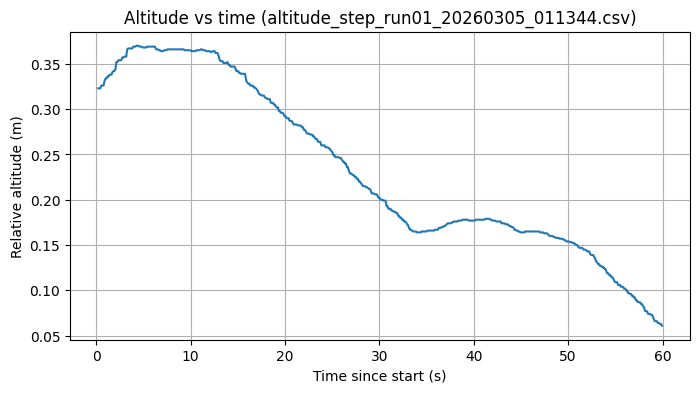

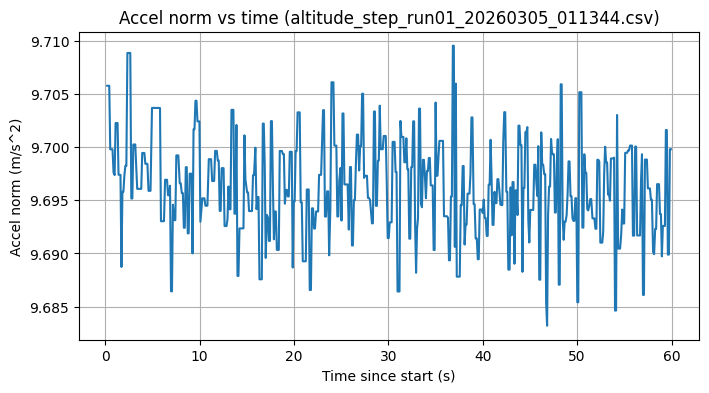

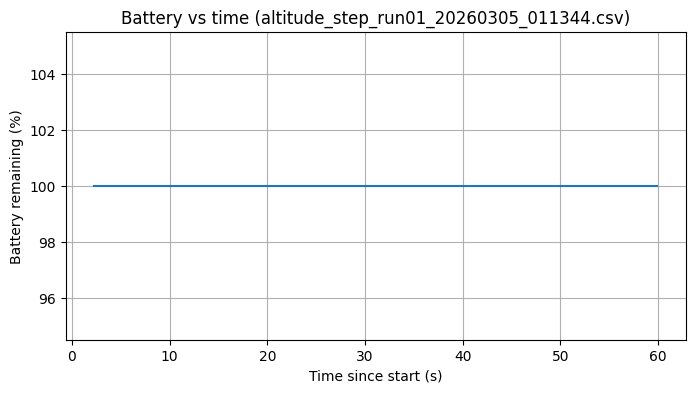

In [6]:
# Pick one run
one_run = all_df[all_df["source_file"] == files[0].name].copy()
one_run["t0"] = one_run["timestamp_unix_s"] - one_run["timestamp_unix_s"].min()

# Altitude vs time
plt.figure(figsize=(8, 4))
plt.plot(one_run["t0"], one_run["rel_alt_m"])
plt.xlabel("Time since start (s)")
plt.ylabel("Relative altitude (m)")
plt.title(f"Altitude vs time ({files[0].name})")
plt.grid(True)
plt.show()

# Accel norm vs time
import numpy as np

accel = np.sqrt(
    one_run["accel_x_mps2"]**2 +
    one_run["accel_y_mps2"]**2 +
    one_run["accel_z_mps2"]**2
)

plt.figure(figsize=(8, 4))
plt.plot(one_run["t0"], accel)
plt.xlabel("Time since start (s)")
plt.ylabel("Accel norm (m/s^2)")
plt.title(f"Accel norm vs time ({files[0].name})")
plt.grid(True)
plt.show()

# Battery remaining vs time
plt.figure(figsize=(8, 4))
plt.plot(one_run["t0"], one_run["battery_remaining_pct"])
plt.xlabel("Time since start (s)")
plt.ylabel("Battery remaining (%)")
plt.title(f"Battery vs time ({files[0].name})")
plt.grid(True)
plt.show()

In [7]:
import math
from pathlib import Path

import pandas as pd


def meters_to_lat(m: float) -> float:
    return m / 111_111.0


def meters_to_lon(m: float, lat_deg: float) -> float:
    return m / (111_111.0 * math.cos(math.radians(lat_deg)))


def inject_spoof(
    df: pd.DataFrame,
    attack_start_s: float = 10.0,
    drift_rate_mps: float = 1.5,
    drift_dir_deg: float = 45.0,
) -> pd.DataFrame:
    out = df.copy()

    # assume df has 'timestamp_unix_s', 'lat_deg', 'lon_deg'
    t0 = out["timestamp_unix_s"].iloc[0]
    elapsed = out["timestamp_unix_s"] - t0

    out["true_lat_deg"] = out["lat_deg"]
    out["true_lon_deg"] = out["lon_deg"]
    out["label"] = "normal"
    out["attack_elapsed_s"] = 0.0

    attack_mask = elapsed >= attack_start_s
    attack_t = (elapsed - attack_start_s).clip(lower=0)

    dir_rad = math.radians(drift_dir_deg)
    drift_north = drift_rate_mps * math.cos(dir_rad) * attack_t
    drift_east = drift_rate_mps * math.sin(dir_rad) * attack_t

    out.loc[attack_mask, "lat_deg"] += drift_north[attack_mask].apply(meters_to_lat)
    out.loc[attack_mask, "lon_deg"] += [
        meters_to_lon(e, lat)
        for e, lat in zip(drift_east[attack_mask], out.loc[attack_mask, "true_lat_deg"])
    ]
    out.loc[attack_mask, "label"] = "attack"
    out.loc[attack_mask, "attack_elapsed_s"] = attack_t[attack_mask].round(3)

    return out

In [8]:
input_dir = Path("data") / "normal_flights" / "raw"
output_dir = Path("data") / "attack_flights" / "raw"
output_dir.mkdir(parents=True, exist_ok=True)

files = sorted(input_dir.glob("*.csv"))
print("Found", len(files), "normal flights")

for f in files:
    df = pd.read_csv(f)
    print("Processing", f.name, "rows:", len(df))

    attack_df = inject_spoof(
        df,
        attack_start_s=10.0,   # change here if you want
        drift_rate_mps=1.5,
        drift_dir_deg=45.0,
    )

    out_name = f"attack_{f.name}"
    out_path = output_dir / out_name
    attack_df.to_csv(out_path, index=False)
    print("  -> wrote", out_path)

Found 51 normal flights
Processing altitude_step_run01_20260305_011344.csv rows: 564
  -> wrote data/attack_flights/raw/attack_altitude_step_run01_20260305_011344.csv
Processing altitude_step_run02_20260305_011509.csv rows: 570
  -> wrote data/attack_flights/raw/attack_altitude_step_run02_20260305_011509.csv
Processing altitude_step_run03_20260305_011621.csv rows: 557
  -> wrote data/attack_flights/raw/attack_altitude_step_run03_20260305_011621.csv
Processing hover_run01_20260305_002533.csv rows: 562
  -> wrote data/attack_flights/raw/attack_hover_run01_20260305_002533.csv
Processing hover_run01_20260305_003558.csv rows: 552
  -> wrote data/attack_flights/raw/attack_hover_run01_20260305_003558.csv
Processing hover_run01_20260305_005140.csv rows: 552
  -> wrote data/attack_flights/raw/attack_hover_run01_20260305_005140.csv
Processing hover_run01_20260305_010542.csv rows: 554
  -> wrote data/attack_flights/raw/attack_hover_run01_20260305_010542.csv
Processing hover_run02_20260305_005421.

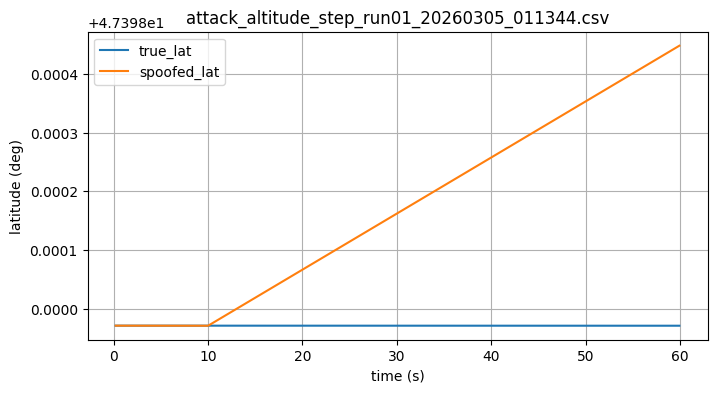

In [9]:
import matplotlib.pyplot as plt

sample_file = sorted((Path("data") / "attack_flights" / "raw").glob("*.csv"))[0]
att = pd.read_csv(sample_file)

t = att["timestamp_unix_s"] - att["timestamp_unix_s"].min()

plt.figure(figsize=(8,4))
plt.plot(t, att["true_lat_deg"], label="true_lat")
plt.plot(t, att["lat_deg"], label="spoofed_lat")
plt.xlabel("time (s)")
plt.ylabel("latitude (deg)")
plt.legend()
plt.grid(True)
plt.title(sample_file.name)
plt.show()

Load and combine data to build ML ready dataset

In [10]:
import pandas as pd
from pathlib import Path

normal_files = sorted((Path("data")/"normal_flights"/"raw").glob("*.csv"))
attack_files = sorted((Path("data")/"attack_flights"/"raw").glob("*.csv"))

dfs = []
for f in normal_files:
    df = pd.read_csv(f)
    df["label"] = 0  # normal
    print(df.columns.tolist())
    dfs.append(df)

for f in attack_files:
    df = pd.read_csv(f)
    df["label"] = 1  # attack
    dfs.append(df)

all_df = pd.concat(dfs, ignore_index=True)

['timestamp_unix_s', 'timestamp_iso', 'scenario', 'run_id', 'lat_deg', 'lon_deg', 'abs_alt_m', 'rel_alt_m', 'accel_x_mps2', 'accel_y_mps2', 'accel_z_mps2', 'gyro_x_rps', 'gyro_y_rps', 'gyro_z_rps', 'battery_remaining_pct', 'battery_voltage_v', 'label']
['timestamp_unix_s', 'timestamp_iso', 'scenario', 'run_id', 'lat_deg', 'lon_deg', 'abs_alt_m', 'rel_alt_m', 'accel_x_mps2', 'accel_y_mps2', 'accel_z_mps2', 'gyro_x_rps', 'gyro_y_rps', 'gyro_z_rps', 'battery_remaining_pct', 'battery_voltage_v', 'label']
['timestamp_unix_s', 'timestamp_iso', 'scenario', 'run_id', 'lat_deg', 'lon_deg', 'abs_alt_m', 'rel_alt_m', 'accel_x_mps2', 'accel_y_mps2', 'accel_z_mps2', 'gyro_x_rps', 'gyro_y_rps', 'gyro_z_rps', 'battery_remaining_pct', 'battery_voltage_v', 'label']
['timestamp_unix_s', 'timestamp_iso', 'scenario', 'run_id', 'lat_deg', 'lon_deg', 'abs_alt_m', 'rel_alt_m', 'accel_x_mps2', 'accel_y_mps2', 'accel_z_mps2', 'gyro_x_rps', 'gyro_y_rps', 'gyro_z_rps', 'battery_remaining_pct', 'battery_voltage_v

LSTM autoencoder

In [11]:
from pathlib import Path
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split

# FEATURE_COLS = ['timestamp_unix_s', 'timestamp_iso', 'scenario', 'run_id',
#  'lat_deg', 'lon_deg', 'abs_alt_m', 'rel_alt_m', 'accel_x_mps2', 'accel_y_mps2',
#   'accel_z_mps2', 'gyro_x_rps', 'gyro_y_rps', 'gyro_z_rps', 'battery_remaining_pct',
#    'battery_voltage_v', 'label']
#do not inclde timestamp_sio or any other ting columns

FEATURE_COLS = [
    "lat_deg", "lon_deg", "rel_alt_m",
    "accel_x_mps2", "accel_y_mps2", "accel_z_mps2",
    "gyro_x_rps", "gyro_y_rps", "gyro_z_rps",
    "battery_remaining_pct",
]
SEQ_LEN = 50

data_root = Path("data")
normal_dir = data_root / "normal_flights" / "raw"
attack_dir = data_root / "attack_flights" / "raw"

normal_files = sorted(normal_dir.glob("*.csv"))
attack_files = sorted(attack_dir.glob("*.csv"))

def load_and_concat(files, label: int):
    dfs = []
    for f in files:
        df = pd.read_csv(f)
        df["label"] = label
        dfs.append(df)
    if not dfs:
        return pd.DataFrame()
    return pd.concat(dfs, ignore_index=True)

df_normal = load_and_concat(normal_files, label=0)
df_attack = load_and_concat(attack_files, label=1)

print("Normal rows:", len(df_normal), "Attack rows:", len(df_attack))

# Drop rows with any missing features
df_normal = df_normal.dropna(subset=FEATURE_COLS)
df_attack = df_attack.dropna(subset=FEATURE_COLS)

Normal rows: 69036 Attack rows: 84578


In [12]:
###############################Normalize using only normal data
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
scaler.fit(df_normal[FEATURE_COLS].values)

X_normal = scaler.transform(df_normal[FEATURE_COLS].values)
X_attack = scaler.transform(df_attack[FEATURE_COLS].values)
y_normal = df_normal["label"].values
y_attack = df_attack["label"].values

############################### turn continours streamsin to fixed-length sequences, Simple sliding window (no overlap control to keep it clear):

In [13]:
def make_sequences(X, y, seq_len):
    seqs = []
    labels = []
    for start in range(0, len(X) - seq_len + 1, seq_len):
        end = start + seq_len
        seq = X[start:end]
        if len(seq) == seq_len:
            seqs.append(seq)
            # for normal data, all labels are 0 anyway; for attack, mark 1 if any attack in window
            labels.append(int(y[start:end].max()))
    return np.stack(seqs), np.array(labels)

Xn_seq, yn_seq = make_sequences(X_normal, y_normal, SEQ_LEN)
Xa_seq, ya_seq = make_sequences(X_attack, y_attack, SEQ_LEN)

print("Normal sequences:", Xn_seq.shape, "Attack sequences:", Xa_seq.shape)

Normal sequences: (1254, 50, 10) Attack sequences: (1532, 50, 10)


########################### train val test split on normal

In [14]:
Xn_train, Xn_temp = train_test_split(Xn_seq, test_size=0.3, random_state=42)
Xn_val,  Xn_test = train_test_split(Xn_temp, test_size=0.5, random_state=42)

# Test set: mix normal + attack for evaluation later
X_test = np.concatenate([Xn_test, Xa_seq], axis=0)
y_test = np.concatenate([np.zeros(len(Xn_test), dtype=int), np.ones(len(Xa_seq), dtype=int)])

print("Train normal:", Xn_train.shape, "Val normal:", Xn_val.shape, "Test total:", X_test.shape)

Train normal: (877, 50, 10) Val normal: (188, 50, 10) Test total: (1721, 50, 10)


############################ pytorch dataset + data loader

In [15]:
import torch
from torch.utils.data import Dataset, DataLoader

class SequenceDataset(Dataset):
    def __init__(self, X):
        # X: (num_seqs, seq_len, num_features), numpy
        self.X = torch.from_numpy(X).float()

    def __len__(self):
        return self.X.shape[0]

    def __getitem__(self, idx):
        return self.X[idx]   # (seq_len, num_features)

train_ds = SequenceDataset(Xn_train)
val_ds   = SequenceDataset(Xn_val)

train_loader = DataLoader(train_ds, batch_size=64, shuffle=True)
val_loader   = DataLoader(val_ds, batch_size=64, shuffle=False)

#####################define hte STM autoencoder


In [16]:

import torch.nn as nn

class LSTMAutoencoder(nn.Module):
    def __init__(self, n_features: int, hidden_size: int = 32, latent_size: int = 16, num_layers: int = 1):
        super().__init__()
        self.n_features = n_features
        self.hidden_size = hidden_size
        self.latent_size = latent_size
        self.num_layers = num_layers

        # Encoder
        self.encoder_lstm = nn.LSTM(
            input_size=n_features,
            hidden_size=hidden_size,
            num_layers=num_layers,
            batch_first=True,
        )
        self.encoder_fc = nn.Linear(hidden_size, latent_size)

        # Decoder
        self.decoder_fc = nn.Linear(latent_size, hidden_size)
        self.decoder_lstm = nn.LSTM(
            input_size=hidden_size,
            hidden_size=n_features,
            num_layers=num_layers,
            batch_first=True,
        )

    def forward(self, x):
        # x: (batch, seq_len, n_features)
        batch_size, seq_len, _ = x.size()

        # Encoder: keep last hidden state
        enc_out, (h_n, c_n) = self.encoder_lstm(x)  # h_n: (num_layers, batch, hidden_size)
        h_last = h_n[-1]  # (batch, hidden_size)

        z = self.encoder_fc(h_last)  # (batch, latent_size)

        # Repeat latent for each time step
        dec_in = self.decoder_fc(z)          # (batch, hidden_size)
        dec_in = dec_in.unsqueeze(1).repeat(1, seq_len, 1)  # (batch, seq_len, hidden_size)

        dec_out, _ = self.decoder_lstm(dec_in)  # (batch, seq_len, n_features)
        return dec_out

####instantiate

In [17]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
n_features = Xn_train.shape[2]

model = LSTMAutoencoder(n_features=n_features, hidden_size=32, latent_size=16).to(device)
criterion = nn.MSELoss(reduction="mean")
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)

#train on normal sequence only

In [18]:

import torch

EPOCHS = 30

for epoch in range(1, EPOCHS + 1):
    model.train()
    train_losses = []

    for batch in train_loader:
        batch = batch.to(device)      # (B, T, F)
        optimizer.zero_grad()
        recon = model(batch)
        loss = criterion(recon, batch)
        loss.backward()
        optimizer.step()
        train_losses.append(loss.item())

    # validation
    model.eval()
    val_losses = []
    with torch.no_grad():
        for batch in val_loader:
            batch = batch.to(device)
            recon = model(batch)
            loss = criterion(recon, batch)
            val_losses.append(loss.item())

    print(f"Epoch {epoch:02d} | train_loss={sum(train_losses)/len(train_losses):.6f} "
          f"| val_loss={sum(val_losses)/len(val_losses):.6f}")

from pathlib import Path

Path("models").mkdir(parents=True, exist_ok=True)
#optionally save
torch.save(model.state_dict(), "models/lstm_autoencoder.pth")


Epoch 01 | train_loss=1.032196 | val_loss=0.971387
Epoch 02 | train_loss=0.979540 | val_loss=0.929721
Epoch 03 | train_loss=0.925200 | val_loss=0.860678
Epoch 04 | train_loss=0.847617 | val_loss=0.801599
Epoch 05 | train_loss=0.797569 | val_loss=0.751423
Epoch 06 | train_loss=0.753013 | val_loss=0.708827
Epoch 07 | train_loss=0.696955 | val_loss=0.673452
Epoch 08 | train_loss=0.669050 | val_loss=0.649054
Epoch 09 | train_loss=0.635286 | val_loss=0.628358
Epoch 10 | train_loss=0.606345 | val_loss=0.614515
Epoch 11 | train_loss=0.589490 | val_loss=0.599707
Epoch 12 | train_loss=0.578592 | val_loss=0.587982
Epoch 13 | train_loss=0.573637 | val_loss=0.584161
Epoch 14 | train_loss=0.566876 | val_loss=0.577716
Epoch 15 | train_loss=0.566387 | val_loss=0.573819
Epoch 16 | train_loss=0.552392 | val_loss=0.570858
Epoch 17 | train_loss=0.559661 | val_loss=0.569762
Epoch 18 | train_loss=0.546633 | val_loss=0.566538
Epoch 19 | train_loss=0.546000 | val_loss=0.564172
Epoch 20 | train_loss=0.552333 

##################### chose an anomaly threshold from validation, Compute per-sequence MSE on validation normal:

In [19]:

import numpy as np

model.eval()
val_errors = []

with torch.no_grad():
    for batch in val_loader:
        batch = batch.to(device)
        recon = model(batch)
        batch_errors = ((recon - batch) ** 2).mean(dim=(1, 2))  # (batch,)
        val_errors.extend(batch_errors.cpu().numpy())

val_errors = np.array(val_errors)
print("Val errors stats:", val_errors.mean(), val_errors.std())


#Define a threshold, e.g. 95th percentile of normal error:
threshold = np.quantile(val_errors, 0.95)
print("Anomaly threshold:", threshold)

# use this to classify sequences as normal vs anomalous.
#evaluate on mixed test data(normal + attack), build a dataloader for X_test

test_ds = SequenceDataset(X_test)
test_loader = DataLoader(test_ds, batch_size=64, shuffle=False)


Val errors stats: 0.55425483 1.3596796
Anomaly threshold: 3.4602413


#compute errors and prediction

In [20]:
#compute errors and predictions


all_errors = []

model.eval()
with torch.no_grad():
    for batch in test_loader:
        batch = batch.to(device)
        recon = model(batch)
        batch_errors = ((recon - batch) ** 2).mean(dim=(1, 2))
        all_errors.extend(batch_errors.cpu().numpy())

all_errors = np.array(all_errors)
y_pred = (all_errors > threshold).astype(int)   # 1 = anomaly/attack


#metrics
from sklearn.metrics import confusion_matrix, classification_report, roc_auc_score

print(confusion_matrix(y_test, y_pred))
print(classification_report(y_test, y_pred, digits=4))
print("ROC AUC:", roc_auc_score(y_test, all_errors))  # using scores, not hard labels

[[ 182    7]
 [ 100 1432]]
              precision    recall  f1-score   support

           0     0.6454    0.9630    0.7728       189
           1     0.9951    0.9347    0.9640      1532

    accuracy                         0.9378      1721
   macro avg     0.8203    0.9488    0.8684      1721
weighted avg     0.9567    0.9378    0.9430      1721

ROC AUC: 0.9686269634050313


##########Quantization and pruning

In [21]:
import torch
from pathlib import Path

device = torch.device("cpu")  # quantized models run on CPU

n_features = Xn_train.shape[2]   # same as before
base_model = LSTMAutoencoder(n_features=n_features, hidden_size=32, latent_size=16)
base_model.load_state_dict(torch.load("models/lstm_autoencoder.pth", map_location="cpu"))
base_model.to(device)
base_model.eval()

LSTMAutoencoder(
  (encoder_lstm): LSTM(10, 32, batch_first=True)
  (encoder_fc): Linear(in_features=32, out_features=16, bias=True)
  (decoder_fc): Linear(in_features=16, out_features=32, bias=True)
  (decoder_lstm): LSTM(32, 10, batch_first=True)
)

#post training dynamic quantization

In [22]:
import torch.nn as nn

quantized_model = torch.quantization.quantize_dynamic(
    base_model, {nn.LSTM, nn.Linear}, dtype=torch.qint8
)
quantized_model.eval()

/tmp/ipykernel_38321/2972949924.py:3: DeprecationWarning: torch.ao.quantization is deprecated and will be removed in 2.10. 
For migrations of users: 
1. Eager mode quantization (torch.ao.quantization.quantize, torch.ao.quantization.quantize_dynamic), please migrate to use torchao eager mode quantize_ API instead 
2. FX graph mode quantization (torch.ao.quantization.quantize_fx.prepare_fx,torch.ao.quantization.quantize_fx.convert_fx, please migrate to use torchao pt2e quantization API instead (prepare_pt2e, convert_pt2e) 
3. pt2e quantization has been migrated to torchao (https://github.com/pytorch/ao/tree/main/torchao/quantization/pt2e) 
see https://github.com/pytorch/ao/issues/2259 for more details
  quantized_model = torch.quantization.quantize_dynamic(


LSTMAutoencoder(
  (encoder_lstm): DynamicQuantizedLSTM(10, 32, batch_first=True)
  (encoder_fc): DynamicQuantizedLinear(in_features=32, out_features=16, dtype=torch.qint8, qscheme=torch.per_tensor_affine)
  (decoder_fc): DynamicQuantizedLinear(in_features=16, out_features=32, dtype=torch.qint8, qscheme=torch.per_tensor_affine)
  (decoder_lstm): DynamicQuantizedLSTM(32, 10, batch_first=True)
)

#compare model size

In [23]:
# save both to compare file size
Path("models").mkdir(exist_ok=True)

torch.save(base_model.state_dict(), "models/lstm_autoencoder_fp32.pth")
torch.save(quantized_model.state_dict(), "models/lstm_autoencoder_int8.pth")

import os
fp32_size = os.path.getsize("models/lstm_autoencoder_fp32.pth") / 1024
int8_size = os.path.getsize("models/lstm_autoencoder_int8.pth") / 1024
print(f"FP32 size: {fp32_size:.1f} KB, INT8 size: {int8_size:.1f} KB")

FP32 size: 37.9 KB, INT8 size: 16.3 KB


######Measure CPU latency

In [24]:
import time
import numpy as np
import torch

def measure_latency(model, X, n_runs=50):
    model.eval()
    ds = SequenceDataset(X)
    loader = DataLoader(ds, batch_size=1, shuffle=False)

    times = []
    with torch.no_grad():
        for i, batch in enumerate(loader):
            if i >= n_runs:
                break
            batch = batch.to("cpu")
            t0 = time.time()
            _ = model(batch)
            times.append(time.time() - t0)
    return np.mean(times) * 1000  # ms

lat_fp32 = measure_latency(base_model, X_test)
lat_int8 = measure_latency(quantized_model, X_test)

print(f"FP32 latency: {lat_fp32:.3f} ms, INT8 latency: {lat_int8:.3f} ms")

FP32 latency: 3.126 ms, INT8 latency: 13.983 ms


####Re‑evaluate detection performance (same threshold pipeline)
####Reuse your earlier evaluation code, but swap model:

In [25]:
def compute_errors(model, loader):
    model.eval()
    errors = []
    with torch.no_grad():
        for batch in loader:
            batch = batch.to("cpu")
            recon = model(batch)
            batch_errors = ((recon - batch) ** 2).mean(dim=(1, 2))
            errors.extend(batch_errors.cpu().numpy())
    return np.array(errors)

# 1) recompute val errors on quantized model to get a new threshold, or reuse old
val_errors_q = compute_errors(quantized_model, val_loader)
threshold_q = np.quantile(val_errors_q, 0.95)

# 2) test metrics
test_errors_q = compute_errors(quantized_model, test_loader)
y_pred_q = (test_errors_q > threshold_q).astype(int)

from sklearn.metrics import confusion_matrix, classification_report, roc_auc_score

print(confusion_matrix(y_test, y_pred_q))
print(classification_report(y_test, y_pred_q, digits=4))
print("ROC AUC:", roc_auc_score(y_test, test_errors_q))

[[ 182    7]
 [ 100 1432]]
              precision    recall  f1-score   support

           0     0.6454    0.9630    0.7728       189
           1     0.9951    0.9347    0.9640      1532

    accuracy                         0.9378      1721
   macro avg     0.8203    0.9488    0.8684      1721
weighted avg     0.9567    0.9378    0.9430      1721

ROC AUC: 0.9794161935154102


#####Note the size before/after, latency before/after, ROC AUC before/after.

In [26]:
import copy
import torch.nn as nn
import torch.nn.utils.prune as prune

pruned_model = copy.deepcopy(base_model)
prune_amount = 0.3

# Collect exactly the parameter names we will prune, per module
to_prune = []  # list of (module, param_name)

for module in pruned_model.modules():
    if isinstance(module, nn.Linear):
        to_prune.append((module, "weight"))

    elif isinstance(module, nn.LSTM):
        # LSTM stores weights as parameters like:
        # weight_ih_l{k}, weight_hh_l{k}, and optionally *_reverse for bidirectional
        for pname in list(module._parameters.keys()):
            if pname is None:
                continue
            if pname.startswith("weight_ih") or pname.startswith("weight_hh"):
                # Skip any already-pruned artifacts just in case
                if pname.endswith("_orig") or pname.endswith("_mask"):
                    continue
                to_prune.append((module, pname))

# Apply pruning
for module, pname in to_prune:
    prune.l1_unstructured(module, name=pname, amount=prune_amount)

# Make pruning permanent (removes mask/orig reparam)
for module, pname in to_prune:
    prune.remove(module, pname)

pruned_model.eval()

LSTMAutoencoder(
  (encoder_lstm): LSTM(10, 32, batch_first=True)
  (encoder_fc): Linear(in_features=32, out_features=16, bias=True)
  (decoder_fc): Linear(in_features=16, out_features=32, bias=True)
  (decoder_lstm): LSTM(32, 10, batch_first=True)
)

####Save and compare size

In [27]:
torch.save(pruned_model.state_dict(), "models/lstm_autoencoder_pruned.pth")
pruned_size = os.path.getsize("models/lstm_autoencoder_pruned.pth") / 1024
print(f"Pruned size: {pruned_size:.1f} KB")

Pruned size: 38.0 KB


### Work on the GRU encoder

In [28]:
import torch
import torch.nn as nn

class GRUAutoencoder(nn.Module):
    def __init__(self, n_features: int, hidden_size: int = 32, latent_size: int = 16, num_layers: int = 1):
        super().__init__()
        self.n_features = n_features
        self.hidden_size = hidden_size
        self.latent_size = latent_size
        self.num_layers = num_layers

        # Encoder
        self.encoder_gru = nn.GRU(
            input_size=n_features,
            hidden_size=hidden_size,
            num_layers=num_layers,
            batch_first=True,
        )
        self.encoder_fc = nn.Linear(hidden_size, latent_size)

        # Decoder
        self.decoder_fc = nn.Linear(latent_size, hidden_size)
        self.decoder_gru = nn.GRU(
            input_size=hidden_size,
            hidden_size=n_features,
            num_layers=num_layers,
            batch_first=True,
        )

    def forward(self, x):
        batch_size, seq_len, _ = x.size()

        # Encoder: keep last hidden state (GRU has no cell state)
        enc_out, h_n = self.encoder_gru(x)
        h_last = h_n[-1]

        z = self.encoder_fc(h_last)

        # Repeat latent for each time step
        dec_in = self.decoder_fc(z)
        dec_in = dec_in.unsqueeze(1).repeat(1, seq_len, 1)

        dec_out, _ = self.decoder_gru(dec_in)
        return dec_out

print(GRUAutoencoder(n_features=10))

GRUAutoencoder(
  (encoder_gru): GRU(10, 32, batch_first=True)
  (encoder_fc): Linear(in_features=32, out_features=16, bias=True)
  (decoder_fc): Linear(in_features=16, out_features=32, bias=True)
  (decoder_gru): GRU(32, 10, batch_first=True)
)


In [29]:
#Instantiate (same hyperparameters as LSTM)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
n_features = Xn_train.shape[2]

gru_model = GRUAutoencoder(n_features=n_features, hidden_size=32, latent_size=16).to(device)
gru_criterion = nn.MSELoss(reduction="mean")
gru_optimizer = torch.optim.Adam(gru_model.parameters(), lr=1e-3)

# Count parameters for comparison
lstm_params = sum(p.numel() for p in model.parameters())
gru_params  = sum(p.numel() for p in gru_model.parameters())
print(f"LSTM params: {lstm_params:,}  |  GRU params: {gru_params:,}  |  Reduction: {1 - gru_params/lstm_params:.1%}")

LSTM params: 8,464  |  GRU params: 6,616  |  Reduction: 21.8%


#Train GRU

In [30]:
EPOCHS = 30
gru_train_hist = []
gru_val_hist = []

for epoch in range(1, EPOCHS + 1):
    gru_model.train()
    train_losses = []

    for batch in train_loader:
        batch = batch.to(device)
        gru_optimizer.zero_grad()
        recon = gru_model(batch)
        loss = gru_criterion(recon, batch)
        loss.backward()
        gru_optimizer.step()
        train_losses.append(loss.item())

    gru_model.eval()
    val_losses = []
    with torch.no_grad():
        for batch in val_loader:
            batch = batch.to(device)
            recon = gru_model(batch)
            loss = gru_criterion(recon, batch)
            val_losses.append(loss.item())

    t_loss = sum(train_losses) / len(train_losses)
    v_loss = sum(val_losses) / len(val_losses)
    gru_train_hist.append(t_loss)
    gru_val_hist.append(v_loss)

    print(f"Epoch {epoch:02d} | train_loss={t_loss:.6f} | val_loss={v_loss:.6f}")

Path("models").mkdir(parents=True, exist_ok=True)
torch.save(gru_model.state_dict(), "models/gru_autoencoder.pth")
print("\nModel saved to models/gru_autoencoder.pth")

Epoch 01 | train_loss=1.013920 | val_loss=0.911313
Epoch 02 | train_loss=0.882920 | val_loss=0.806472
Epoch 03 | train_loss=0.776123 | val_loss=0.726274
Epoch 04 | train_loss=0.710297 | val_loss=0.685269
Epoch 05 | train_loss=0.672198 | val_loss=0.659484
Epoch 06 | train_loss=0.643392 | val_loss=0.638467
Epoch 07 | train_loss=0.622705 | val_loss=0.624084
Epoch 08 | train_loss=0.617831 | val_loss=0.612679
Epoch 09 | train_loss=0.591078 | val_loss=0.604380
Epoch 10 | train_loss=0.590109 | val_loss=0.597840
Epoch 11 | train_loss=0.589826 | val_loss=0.593441
Epoch 12 | train_loss=0.578118 | val_loss=0.587502
Epoch 13 | train_loss=0.568637 | val_loss=0.582202
Epoch 14 | train_loss=0.565502 | val_loss=0.577292
Epoch 15 | train_loss=0.558106 | val_loss=0.572437
Epoch 16 | train_loss=0.554015 | val_loss=0.567914
Epoch 17 | train_loss=0.553537 | val_loss=0.564933
Epoch 18 | train_loss=0.550286 | val_loss=0.561256
Epoch 19 | train_loss=0.543189 | val_loss=0.558698
Epoch 20 | train_loss=0.540065 

#GRU Anomaly Threshold

In [31]:
import numpy as np

gru_model.eval()
gru_val_errors = []

with torch.no_grad():
    for batch in val_loader:
        batch = batch.to(device)
        recon = gru_model(batch)
        batch_errors = ((recon - batch) ** 2).mean(dim=(1, 2))
        gru_val_errors.extend(batch_errors.cpu().numpy())

gru_val_errors = np.array(gru_val_errors)
gru_threshold = np.quantile(gru_val_errors, 0.95)
print(f"GRU val errors — mean: {gru_val_errors.mean():.6f}, std: {gru_val_errors.std():.6f}")
print(f"GRU anomaly threshold (95th pct): {gru_threshold:.6f}")
print(f"LSTM anomaly threshold was:        {threshold:.6f}")

GRU val errors — mean: 0.541847, std: 1.332875
GRU anomaly threshold (95th pct): 3.403265
LSTM anomaly threshold was:        3.460241


#Evaluate GRU on Test Set

In [32]:
from sklearn.metrics import confusion_matrix, classification_report, roc_auc_score

gru_test_errors = []
gru_model.eval()
with torch.no_grad():
    for batch in test_loader:
        batch = batch.to(device)
        recon = gru_model(batch)
        batch_errors = ((recon - batch) ** 2).mean(dim=(1, 2))
        gru_test_errors.extend(batch_errors.cpu().numpy())

gru_test_errors = np.array(gru_test_errors)
gru_y_pred = (gru_test_errors > gru_threshold).astype(int)

print("=== GRU Autoencoder Results ===")
print(confusion_matrix(y_test, gru_y_pred))
print(classification_report(y_test, gru_y_pred, digits=4))
gru_roc = roc_auc_score(y_test, gru_test_errors)
print(f"ROC AUC: {gru_roc:.6f}")

=== GRU Autoencoder Results ===
[[ 182    7]
 [ 100 1432]]
              precision    recall  f1-score   support

           0     0.6454    0.9630    0.7728       189
           1     0.9951    0.9347    0.9640      1532

    accuracy                         0.9378      1721
   macro avg     0.8203    0.9488    0.8684      1721
weighted avg     0.9567    0.9378    0.9430      1721

ROC AUC: 0.968869


In [33]:
#GRU INT8 quantization +size comparison
# ===== GRU INT8 Quantization =====
import torch.nn as nn

# Quantize the trained GRU model
gru_quantized = torch.quantization.quantize_dynamic(
    gru_model, {nn.GRU, nn.Linear}, dtype=torch.qint8
)
gru_quantized.eval()

# Save and compare size
torch.save(gru_model.state_dict(), "models/gru_autoencoder_fp32.pth")
torch.save(gru_quantized.state_dict(), "models/gru_autoencoder_int8.pth")

import os
gru_fp32_size = os.path.getsize("models/gru_autoencoder_fp32.pth") / 1024
gru_int8_size = os.path.getsize("models/gru_autoencoder_int8.pth") / 1024
print(f"GRU FP32 size: {gru_fp32_size:.1f} KB, GRU INT8 size: {gru_int8_size:.1f} KB")

GRU FP32 size: 30.7 KB, GRU INT8 size: 14.3 KB


/tmp/ipykernel_38321/1098234305.py:6: DeprecationWarning: torch.ao.quantization is deprecated and will be removed in 2.10. 
For migrations of users: 
1. Eager mode quantization (torch.ao.quantization.quantize, torch.ao.quantization.quantize_dynamic), please migrate to use torchao eager mode quantize_ API instead 
2. FX graph mode quantization (torch.ao.quantization.quantize_fx.prepare_fx,torch.ao.quantization.quantize_fx.convert_fx, please migrate to use torchao pt2e quantization API instead (prepare_pt2e, convert_pt2e) 
3. pt2e quantization has been migrated to torchao (https://github.com/pytorch/ao/tree/main/torchao/quantization/pt2e) 
see https://github.com/pytorch/ao/issues/2259 for more details
  gru_quantized = torch.quantization.quantize_dynamic(


In [34]:
# Measure GRU INT8 latency
gru_lat_fp32 = measure_latency(gru_model, X_test)
gru_lat_int8 = measure_latency(gru_quantized, X_test)
print(f"GRU FP32 latency: {gru_lat_fp32:.3f} ms, GRU INT8 latency: {gru_lat_int8:.3f} ms")

GRU FP32 latency: 14.841 ms, GRU INT8 latency: 8.366 ms


In [35]:
# Re-evaluate GRU INT8 detection performance
gru_val_errors_q = compute_errors(gru_quantized, val_loader)
gru_threshold_q = np.quantile(gru_val_errors_q, 0.95)

gru_test_errors_q = compute_errors(gru_quantized, test_loader)
gru_y_pred_q = (gru_test_errors_q > gru_threshold_q).astype(int)

print(confusion_matrix(y_test, gru_y_pred_q))
print(classification_report(y_test, gru_y_pred_q, digits=4))
gru_int8_roc = roc_auc_score(y_test, gru_test_errors_q)
print(f"GRU INT8 ROC AUC: {gru_int8_roc:.6f}")

[[ 182    7]
 [ 100 1432]]
              precision    recall  f1-score   support

           0     0.6454    0.9630    0.7728       189
           1     0.9951    0.9347    0.9640      1532

    accuracy                         0.9378      1721
   macro avg     0.8203    0.9488    0.8684      1721
weighted avg     0.9567    0.9378    0.9430      1721

GRU INT8 ROC AUC: 0.985042


###LSTM vs GRU Comparison Table + Plots

                     Metric   LSTM    GRU
                 Parameters  8,464  6,616
            Model size (KB)   37.8   30.6
                    ROC AUC 0.9686 0.9689
       Threshold (95th pct) 3.4602 3.4033
              Test accuracy 0.9378 0.9378
Anomaly precision (class 0) 0.6454 0.6454
   Anomaly recall (class 0) 0.9630 0.9630


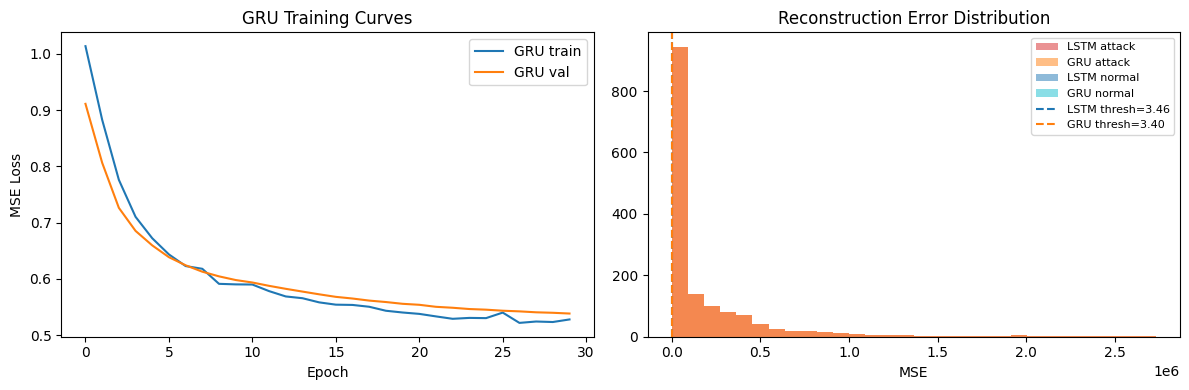


Comparison plot saved to models/lstm_vs_gru_comparison.png


In [36]:
import matplotlib.pyplot as plt
import os

lstm_roc = roc_auc_score(y_test, all_errors)

lstm_size = os.path.getsize("models/lstm_autoencoder.pth") / 1024
gru_size  = os.path.getsize("models/gru_autoencoder.pth") / 1024

comparison = pd.DataFrame({
    "Metric": ["Parameters", "Model size (KB)", "ROC AUC", "Threshold (95th pct)",
               "Test accuracy", "Anomaly precision (class 0)", "Anomaly recall (class 0)"],
    "LSTM": [
        f"{lstm_params:,}",
        f"{lstm_size:.1f}",
        f"{lstm_roc:.4f}",
        f"{threshold:.4f}",
        f"{(y_pred == y_test).mean():.4f}",
        f"{confusion_matrix(y_test, y_pred)[0,0] / (confusion_matrix(y_test, y_pred)[0,0] + confusion_matrix(y_test, y_pred)[1,0]):.4f}",
        f"{confusion_matrix(y_test, y_pred)[0,0] / (confusion_matrix(y_test, y_pred)[0,0] + confusion_matrix(y_test, y_pred)[0,1]):.4f}",
    ],
    "GRU": [
        f"{gru_params:,}",
        f"{gru_size:.1f}",
        f"{gru_roc:.4f}",
        f"{gru_threshold:.4f}",
        f"{(gru_y_pred == y_test).mean():.4f}",
        f"{confusion_matrix(y_test, gru_y_pred)[0,0] / (confusion_matrix(y_test, gru_y_pred)[0,0] + confusion_matrix(y_test, gru_y_pred)[1,0]):.4f}",
        f"{confusion_matrix(y_test, gru_y_pred)[0,0] / (confusion_matrix(y_test, gru_y_pred)[0,0] + confusion_matrix(y_test, gru_y_pred)[0,1]):.4f}",
    ],
})
print(comparison.to_string(index=False))

# --- Plots ---
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(gru_train_hist, label="GRU train")
axes[0].plot(gru_val_hist,   label="GRU val")
axes[0].set_title("GRU Training Curves")
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("MSE Loss")
axes[0].legend()

axes[1].hist(all_errors[y_test == 1], bins=30, alpha=0.5, label="LSTM attack", color="tab:red")
axes[1].hist(gru_test_errors[y_test == 1], bins=30, alpha=0.5, label="GRU attack", color="tab:orange")
axes[1].hist(all_errors[y_test == 0], bins=15, alpha=0.5, label="LSTM normal", color="tab:blue")
axes[1].hist(gru_test_errors[y_test == 0], bins=15, alpha=0.5, label="GRU normal", color="tab:cyan")
axes[1].axvline(threshold, color="tab:blue", ls="--", label=f"LSTM thresh={threshold:.2f}")
axes[1].axvline(gru_threshold, color="tab:orange", ls="--", label=f"GRU thresh={gru_threshold:.2f}")
axes[1].set_title("Reconstruction Error Distribution")
axes[1].set_xlabel("MSE")
axes[1].legend(fontsize=8)

plt.tight_layout()
plt.savefig("models/lstm_vs_gru_comparison.png", dpi=150)
plt.show()
print("\nComparison plot saved to models/lstm_vs_gru_comparison.png")